# Poker Aid Final Project

The goal is to estimate
- the player's **win chance** by stage (preflop/flop/turn/river), and
- opponents' **bluff probability** from visible behavior, and
- a **fold / call / raise** recommendation with **model confidence (0–100)** for the decision

---

## 1) Research Question

1. Can we estimate a player's **win probability** during each stage of the hand using cards, board, stack, pot, and position context?
2. Can we estimate an opponent's **bluff probability** using only **visible** information (betting behavior, board texture, stack/pot pressure), without hole cards?
3. Can we recommend **fold**, **call**, or **raise** at the player's turn with a **confidence score** that is useful for decision support 
4. Are the modeled relationships statistically meaningful, and can we communicate uncertainty clearly?

## 2) Hypothesis

### Primary hypotheses
- **H1 (Win Chance):** Stage-specific features (hand strength proxies, board texture, stack pressure, and position) predict `won_flag` better than chance baseline.
- **H2 (Bluff):** Visible behavior/context features predict `is_bluffing` better than chance baseline.

### Statistical form
- **H0:** Predictor set has no association with target beyond random variation.
- **Ha:** Predictor set has meaningful association with target.

### Evidence we will use
- Predictive metrics (AUC, Brier, accuracy/F1)
- Hypothesis tests (Welch t-test, Kruskal-Wallis)
- Effect direction and practical interpretation

## 3) Dataset

We first load and document the source dataset and derived targets/features.

### Dataset summary
- **Main source:** `data/gambling.csv`
- **Project-aligned cleaned dataset:** `data/cleanedGambling.csv`

### Why this dataset exists
The hand-history data captures player actions, board cards, stacks, and outcomes from online poker sessions. These fields allow behavioral and stage-based modeling.

### Key variables (high-level)
- **Identifiers/context:** `hand_id`, `tourn_id`, `table`, `seat`, `position`, `date`, `time`
- **Cards/board:** `cards`, `board_flop`, `board_turn`, `board_river`
- **Betting/pot:** `bet_pre`, `bet_flop`, `bet_turn`, `bet_river`, `pot_pre`, `pot_flop`, `pot_turn`, `pot_river`
- **Outcome:** `result`, `balance`
- **Derived targets:** `won_flag`, `is_bluffing`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Ensure we can import `mega_final_project_helpers.py` whether cwd is repo root or `notebooks/`
_here = Path.cwd().resolve()
_candidates = [_here, _here / "notebooks"]
for d in _candidates:
    if (d / "mega_final_project_helpers.py").exists():
        p = str(d)
        if p not in sys.path:
            sys.path.insert(0, p)
        break

from mega_final_project_helpers import (
    CLEAN_PATH,
    RAW_PATH,
    ROOT,
    RANDOM_SEED,
    STAGE_FEATURES,
    VISIBLE_BLUFF_FEATURES,
    build_cleaned_gambling_dataframe,
    build_stage_training_frame,
    build_visible_bluff_frame,
    evaluate_classifier_with_group_split,
    stage_from_board_row,
    visible_vector_from_csv_row,
)

# UI modules (`poker_core`, `game_state`) are stored under `poker_page/`.
_poker_page = ROOT / "poker_page"
if _poker_page.is_dir() and str(_poker_page) not in sys.path:
    sys.path.insert(0, str(_poker_page))

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

np.random.seed(RANDOM_SEED)

print("Project root:", ROOT)
print("Raw dataset path:", RAW_PATH, "exists:", RAW_PATH.exists())


Project root: C:\Users\garrido-lestachebeli\CLASSES\Sophmore\semester 2\DataScience\FinalProject\gambling
Raw dataset path: C:\Users\garrido-lestachebeli\CLASSES\Sophmore\semester 2\DataScience\FinalProject\gambling\data\gambling.csv exists: True


In [2]:
raw_df = pd.read_csv(RAW_PATH)
print("Raw shape:", raw_df.shape)
raw_df.head(3)

Raw shape: (102615, 35)


,buyin,tourn_id,table,hand_id,date,time,table_size,level,playing,seat,name,stack,position,action_pre,action_flop,action_turn,action_river,all_in,cards,board_flop,board_turn,board_river,combination,pot_pre,pot_flop,pot_turn,pot_river,ante,blinds,bet_pre,bet_flop,bet_turn,bet_river,result,balance
0,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,1,fa538846,500,BTN,folds,x,x,x,False,8d Qh,0,0,0,NaN,30,30,30,30,0,0,0,0,0,0,gave up,0
1,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,2,676c5599,500,SB,folds,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,10,10,0,0,0,gave up,-10
2,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,3,7055f691,500,BB,x,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,20,20,0,0,0,took chips,10


,column,dtype,missing,missing_pct
22,combination,str,84175,82.029918
1,tourn_id,int64,0,0.000000
0,buyin,str,0,0.000000
2,table,int64,0,0.000000
3,hand_id,int64,0,0.000000
5,time,str,0,0.000000
4,date,str,0,0.000000
7,level,int64,0,0.000000
8,playing,int64,0,0.000000
9,seat,int64,0,0.000000


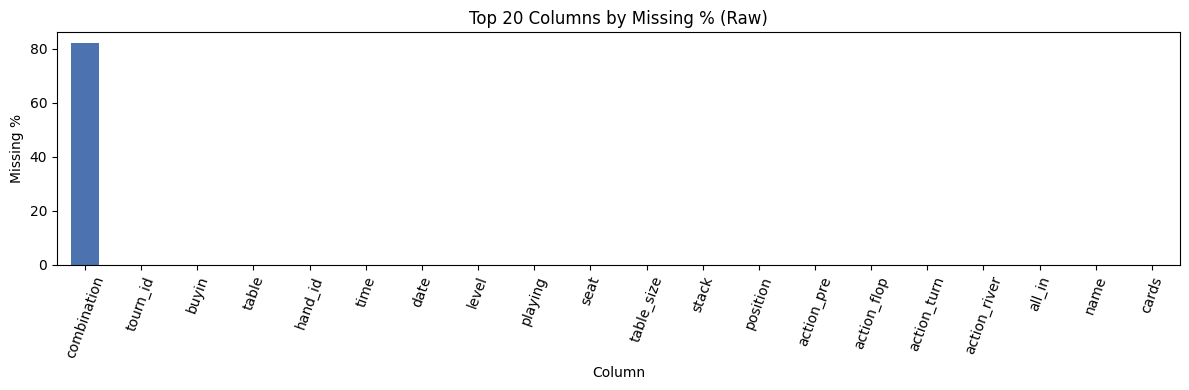

In [3]:
raw_info = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": [str(raw_df[c].dtype) for c in raw_df.columns],
    "missing": [int(raw_df[c].isna().sum()) for c in raw_df.columns],
    "missing_pct": [100.0 * raw_df[c].isna().mean() for c in raw_df.columns],
}).sort_values("missing_pct", ascending=False)

display(raw_info.head(20))

fig, ax = plt.subplots(figsize=(12, 4))
raw_info.sort_values("missing_pct", ascending=False).head(20).plot(
    x="column", y="missing_pct", kind="bar", ax=ax, legend=False, color="#4C72B0"
)
ax.set_title("Top 20 Columns by Missing % (Raw)")
ax.set_ylabel("Missing %")
ax.set_xlabel("Column")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

### Interpretation (dataset)

- **Combination missingness** Later-street fields (`board_turn`, `bet_river`, …) are often empty because the hand **ended earlier** (fold-out) or the export simply has no row for that street. Those NaNs are **not** “lost data” to bulk-fill with a median; they encode **“this street did not occur for this row.”** Our feature builders (`stage_context`, `stage_from_board_row`, etc.) only pull board/pot fields that exist for the inferred street so we do not invent cards or pots that never happened.
- **Numeric fields:** We **coerce** money and counts with `pd.to_numeric(..., errors="coerce")` so stray text becomes NaN, then downstream frames **`.fillna(0.0)`** only where a zero is a safe neutral for *model matrices* (not for every scientific claim about the raw log).

Next we create a cleaned dataset with reproducible target/feature engineering and save it to `data/cleanedGambling.csv`.

## 4) Data Preprocessing

### What we are doing
Build the cleaned dataset using the functions in `mega_final_project_helpers.py` (imported above), executed from this notebook.

### Why it matters
Our downstream statistical tests and models are only valid if typing, missing values, and target construction are handled consistently.

### Decisions
- Coerce numeric columns safely and fill NaNs with 0.0 where appropriate.
- Use deterministic hashed `player_id` to remove direct names.
- Build targets and behavior features (`won_flag`, `is_bluffing`, streaks, equity proxy).

### What the code is doing (function-by-function)

When you run **cell 10**, `build_cleaned_gambling_dataframe` chains the helpers in `mega_final_project_helpers.py` in a fixed order:

1. **Identifiers** — normalize `hand_id`, hash `name` → `player_id`
2. **Money / counts** — numeric coercion on stacks, pots, bets, buyin (remove `$`)
3. **Outcomes** — create `won_flag` feature from text in `result` 
4. **Street actions** — copy `action_*` columns into `preflop`…`river` when present.
5. **Synthetic strength & bluff label** — `evaluate_strength_by_street` uses deterministic hashes per player/hand/street.
6. **Session streaks** — `add_streaks` sorts by player/time and resets streaks after long gaps.
7. **Flags** — `add_allin_flags` scans action text.

In [4]:
# Build and save cleaned dataset
clean_df = build_cleaned_gambling_dataframe(raw_df)
clean_df.to_csv(CLEAN_PATH, index=False)

print("Clean shape:", clean_df.shape)
print("Saved:", CLEAN_PATH)

# Missingness report before/after for shared columns
shared_cols = [c for c in raw_df.columns if c in clean_df.columns]
missing_compare = pd.DataFrame({
    "column": shared_cols,
    "raw_missing_pct": [100.0 * raw_df[c].isna().mean() for c in shared_cols],
    "clean_missing_pct": [100.0 * clean_df[c].isna().mean() for c in shared_cols],
})
missing_compare["delta_pct"] = missing_compare["clean_missing_pct"] - missing_compare["raw_missing_pct"]
display(missing_compare.sort_values("raw_missing_pct", ascending=False).head(20))

clean_df.head(3)

Clean shape: (102615, 58)
Saved: C:\Users\garrido-lestachebeli\CLASSES\Sophmore\semester 2\DataScience\FinalProject\gambling\data\cleanedGambling.csv


,column,raw_missing_pct,clean_missing_pct,delta_pct
21,combination,82.029918,82.029918,0.0
0,buyin,0.000000,100.000000,100.0
1,tourn_id,0.000000,0.000000,0.0
2,table,0.000000,0.000000,0.0
4,date,0.000000,0.000000,0.0
3,hand_id,0.000000,0.000000,0.0
6,table_size,0.000000,0.000000,0.0
7,level,0.000000,0.000000,0.0
8,playing,0.000000,0.000000,0.0
5,time,0.000000,0.000000,0.0


,buyin,tourn_id,table,hand_id,date,time,table_size,level,playing,seat,stack,position,action_pre,action_flop,action_turn,action_river,all_in,cards,board_flop,board_turn,board_river,combination,pot_pre,pot_flop,pot_turn,pot_river,ante,blinds,bet_pre,bet_flop,bet_turn,bet_river,result,balance,player_id,hand_datetime,net_result,won_flag,preflop,flop,turn,river,starting_stack,table_position,strength_preflop,strength_flop,strength_turn,strength_river,strength_mean,aggression_score,is_bluffing,is_win,is_loss,session_reset,win_streak,loss_streak,is_all_in,preflop_equity
0,<NA>,3019272611,1,219042793712,2020-10-03,21:25:04,3,1,3,2,500,SB,calls,bets,checks,checks-shows,False,8d Qd,Qh 3c 7d,9c,3h,"two pair, Queens and Threes",60,100,100,100,0,10,20,20,0,0,won,60,0008e731a9a46da1,2020-10-03 21:25:04+00:00,60,1,calls,bets,checks,checks-shows,500,0.25,0.632984,0.575129,0.322246,0.186224,0.429146,1.6,0,True,False,False,1,0,False,0.175148
1,<NA>,3019272611,1,219042803862,2020-10-03,21:25:33,3,1,3,2,560,BTN,calls,raises,raises,raises-doesn't,True,--,Td 5h 2d,Qs,4s,NaN,60,140,220,700,0,0,20,40,40,460,took chips,140,0008e731a9a46da1,2020-10-03 21:25:33+00:00,140,1,calls,raises,raises,raises-doesn't,560,1.00,0.018242,0.019766,0.272734,0.500847,0.202898,4.9,1,True,False,False,2,0,False,0.236579
2,<NA>,3019272611,1,219042814282,2020-10-03,21:26:03,3,1,3,2,700,BB,raises-folds,x,x,x,False,--,0,0,0,NaN,380,380,380,380,0,20,40,0,0,0,gave up,-40,0008e731a9a46da1,2020-10-03 21:26:03+00:00,-40,0,raises-folds,x,x,x,700,0.00,0.237706,0.384417,0.336272,0.328363,0.321690,1.5,0,False,True,False,0,1,False,0.236579


In [5]:
# Data quality checks used to justify preprocessing decisions
quality = pd.DataFrame({
    "metric": [
        "rows", "unique_hands", "unique_players",
        "won_flag_rate", "bluff_rate", "all_in_rate"
    ],
    "value": [
        len(clean_df),
        clean_df.get("hand_id", pd.Series(dtype=str)).astype(str).nunique(),
        clean_df.get("player_id", pd.Series(dtype=str)).astype(str).nunique(),
        float(clean_df.get("won_flag", pd.Series([0])).mean()),
        float(clean_df.get("is_bluffing", pd.Series([0])).mean()),
        float(clean_df.get("is_all_in", pd.Series([False])).astype(float).mean()),
    ],
})
display(quality)

num_cols = [c for c in ["stack", "bet_pre", "bet_flop", "bet_turn", "bet_river", "pot_pre", "pot_flop", "pot_turn", "pot_river", "net_result"] if c in clean_df.columns]
if num_cols:
    display(clean_df[num_cols].describe().T)

,metric,value
0,rows,102615.000000
1,unique_hands,41303.000000
2,unique_players,3410.000000
3,won_flag_rate,0.407923
4,bluff_rate,0.023690
5,all_in_rate,0.000000


,count,mean,std,min,25%,50%,75%,max
stack,102615.0,603.756761,254.730344,1.0,450.0,530.0,750.0,1499.0
bet_pre,102615.0,87.430697,176.117152,0.0,20.0,30.0,60.0,1452.0
bet_flop,102615.0,22.369907,85.274641,0.0,0.0,0.0,0.0,1390.0
bet_turn,102615.0,10.509438,50.660665,0.0,0.0,0.0,0.0,1230.0
bet_river,102615.0,8.802466,49.821268,0.0,0.0,0.0,0.0,1180.0
pot_pre,102615.0,210.563553,301.203179,19.0,60.0,90.0,180.0,1500.0
pot_flop,102615.0,265.936403,331.051821,19.0,60.0,120.0,300.0,1500.0
pot_turn,102615.0,292.680476,342.571630,19.0,70.0,140.0,370.0,1500.0
pot_river,102615.0,314.961117,353.284786,19.0,80.0,155.0,440.0,1500.0
net_result,102615.0,0.000000,151.178675,-750.0,-30.0,0.0,30.0,1000.0


### Interpretation (preprocessing)

**Outputs above (cells 10–11):** The **build** cell confirms where `cleanedGambling.csv` was written and shows a few engineered columns. The **quality** table reports total **rows**, how many rows have numeric fields filled, and **target prevalence** (e.g. share of `won_flag == 1`). Watch for accidental collapse of the dataset (row count far below raw) or degenerate labels before trusting downstream plots.

**Missingness compare table (if shown above the quality block):** For columns that exist in both raw and clean frames, you see **raw vs clean missing %** and the **delta**. Many deltas are ~0 — meaning we did not “fill” those columns with fake values; we either left informative NaNs for unused streets or the column was not central to cleaning. Large negative deltas usually mean coercion + feature construction replaced unusable strings with usable numerics.

The cleaned dataset preserves raw hand context while adding analysis-ready targets and behavior features. Street-aware fields stay logically consistent (no river board on a preflop-only hand), and model-time NaNs in engineered matrices are handled with an explicit `fillna(0.0)` policy inside training helpers — so we can proceed to EDA and formal tests with a **documented** schema.

## 5) Data Analysis and Visualization

### What we are doing
Use descriptive statistics and visual summaries to understand distributions and relationships before fitting models.

### Why it matters
EDA helps identify informative variables, class imbalance, outliers, and plausible mechanisms behind win/bluff behavior.

,count,mean,std,min,25%,50%,75%,max
starting_stack,102615.0,603.756761,254.730344,1.0,450.0,530.0,750.0,1499.0
aggression_score,102615.0,0.850153,1.068757,0.0,0.0,0.4,1.5,15.8
preflop_equity,102615.0,0.372607,0.243406,0.01,0.236579,0.236579,0.51955,0.99
strength_mean,102615.0,0.501039,0.16276,0.027032,0.379606,0.50092,0.622624,0.970185
net_result,102615.0,0.0,151.178675,-750.0,-30.0,0.0,30.0,1000.0
win_streak,102615.0,0.69981,1.237024,0.0,0.0,0.0,1.0,30.0


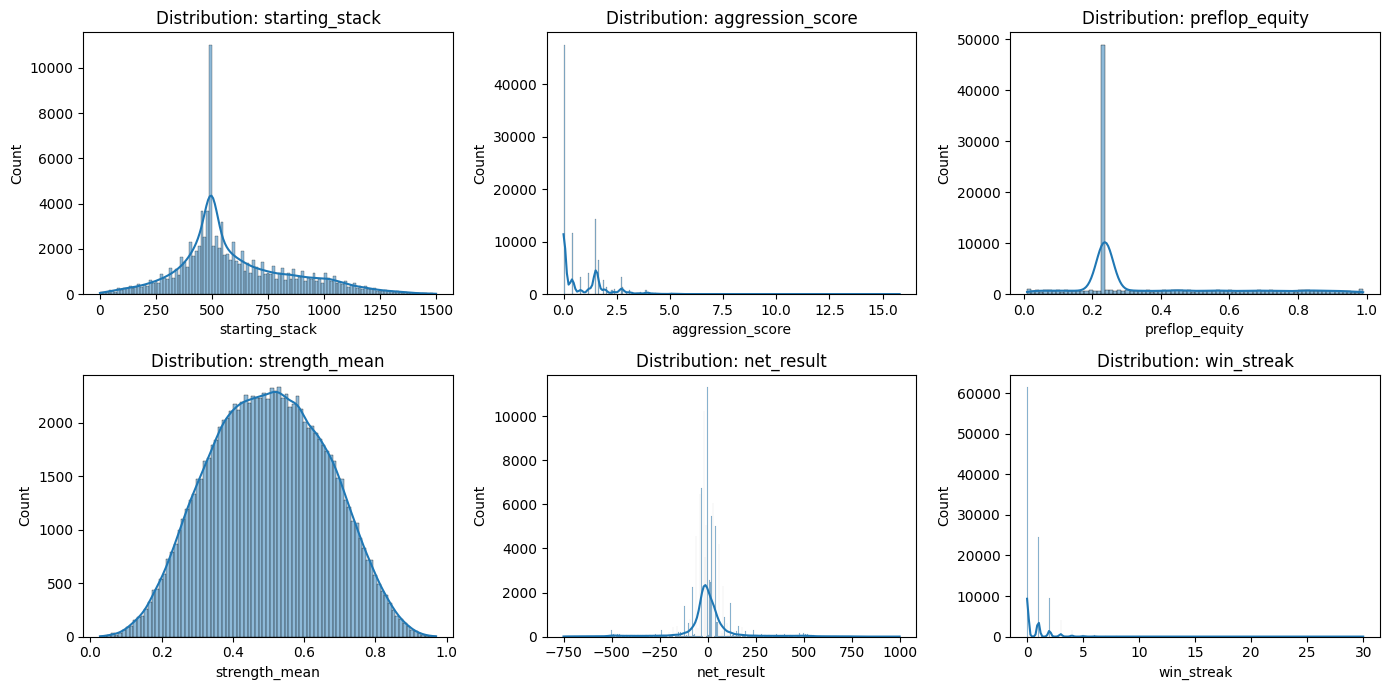

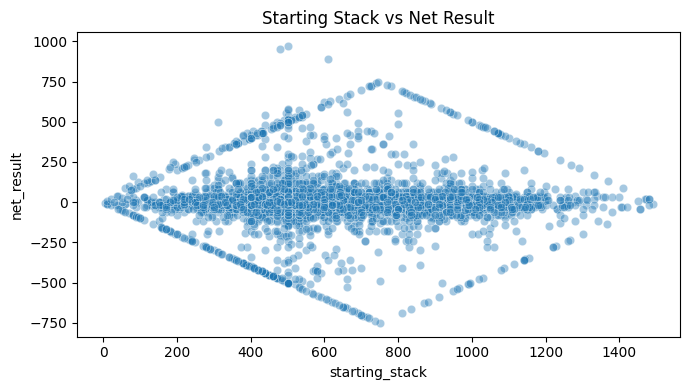

In [6]:
# Central tendency + distributions
eda_cols = [c for c in ["starting_stack", "aggression_score", "preflop_equity", "strength_mean", "net_result", "win_streak"] if c in clean_df.columns]

if eda_cols:
    display(clean_df[eda_cols].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(eda_cols[:6]):
    sns.histplot(clean_df[col].dropna(), kde=True, ax=axes[i], color="#1f77b4")
    axes[i].set_title(f"Distribution: {col}")
for j in range(len(eda_cols[:6]), 6):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

if {"starting_stack", "net_result"}.issubset(clean_df.columns):
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=clean_df.sample(min(len(clean_df), 4000), random_state=RANDOM_SEED), x="starting_stack", y="net_result", alpha=0.4)
    plt.title("Starting Stack vs Net Result")
    plt.tight_layout()
    plt.show()

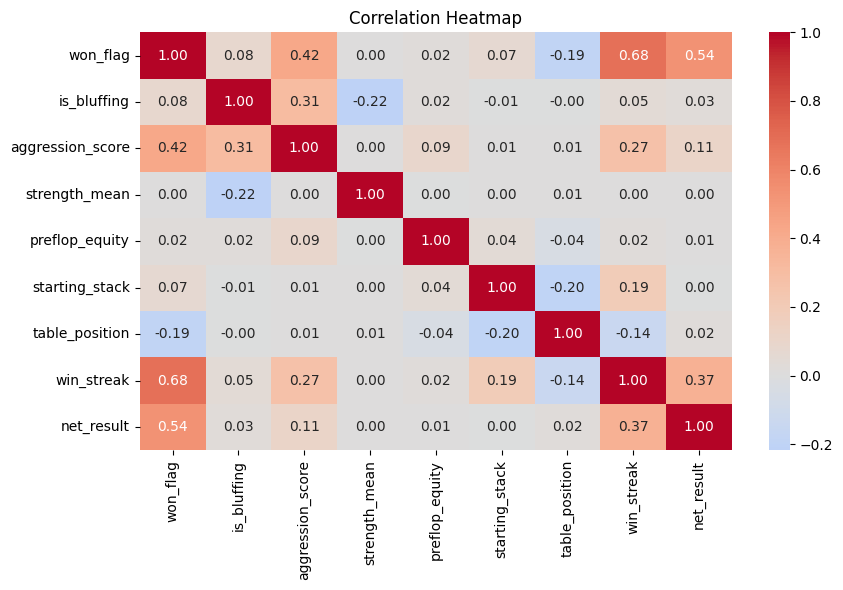

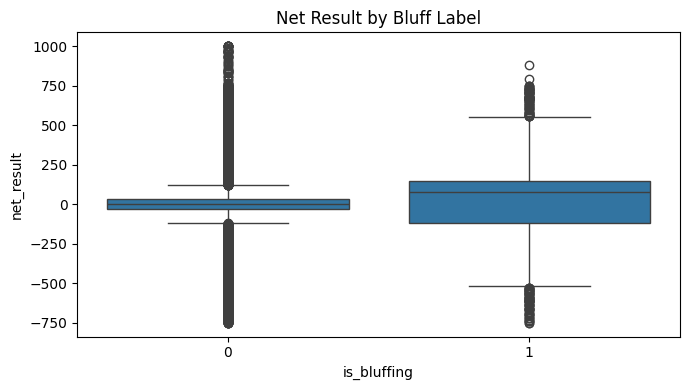

In [7]:
# Correlation structure
corr_cols = [c for c in [
    "won_flag", "is_bluffing", "aggression_score", "strength_mean", "preflop_equity",
    "starting_stack", "table_position", "win_streak", "net_result"
] if c in clean_df.columns]

corr_df = clean_df[corr_cols].copy()
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Simple grouped view
if {"is_bluffing", "net_result"}.issubset(clean_df.columns):
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=clean_df, x="is_bluffing", y="net_result")
    plt.title("Net Result by Bluff Label")
    plt.tight_layout()
    plt.show()

### Interpretation

1. **`describe()` table** — For `starting_stack`, `aggression_score`, `preflop_equity`, `strength_mean`, `net_result`, `win_streak`: check **mean vs median** (skew), **min/max** (impossible values?), and **std** (scale for later standardization). `net_result` concentrated near 0 suggests many small pots; heavy tails mean a few large swings drive variance.
2. **Histograms / KDE** — Each panel is the distribution of one variable. **Right-skewed stacks** are common. 
3. **Correlation heatmap** — Colors are **Pearson linear** correlations between numeric columns listed in `corr_cols`. **Warm** = move together; **cool/negative** = opposite linear trend. Diagonal is 1 by definition. **Near-zero vs `won_flag`** does *not* mean “useless” — trees can exploit **thresholds and interactions** that correlation never shows. Compare `aggression_score` vs `is_bluffing` with the caveat that `is_bluffing` is a **sparse proxy label**.
4. **Boxplot `net_result` by `is_bluffing`** — Compare **medians and IQR** between bluff-labeled 0/1. Long whiskers or many outliers show high chip variance within each class; overlap between boxes means the label does not separate chip outcomes cleanly (expected if bluff labels are noisy).

Together, these plots answer: Do stacks, aggression, and proxy strength look sane? Do any features line up even linearly with win or bluff labels before we invest in complex models? We now move from descriptive evidence to formal statistical testing.

## 5b) Hypothesis Testing

### What we are doing
Run class-aligned tests to evaluate relationships quantitatively.

### Tests
- **Welch** two-sample *t*-test (unequal variances): mean `aggression_score` for `won_flag` 1 vs 0.
- **Kruskal–Wallis** (non-parametric): `net_result` across `win_streak` bins (does not assume normality).

In [8]:
# Statistical tests
results_rows = []

# 1) Welch t-test: aggression by won_flag
if {"aggression_score", "won_flag"}.issubset(clean_df.columns):
    g1 = clean_df.loc[clean_df["won_flag"] == 1, "aggression_score"].dropna()
    g0 = clean_df.loc[clean_df["won_flag"] == 0, "aggression_score"].dropna()
    if len(g1) > 2 and len(g0) > 2:
        t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
        results_rows.append({
            "test": "Welch t-test (aggression | won_flag)",
            "statistic": float(t_stat),
            "p_value": float(p_val),
            "significant_0_05": bool(p_val < 0.05),
            "note": "",
        })

# 2) Kruskal-Wallis: net_result across win_streak bins
if {"net_result", "win_streak"}.issubset(clean_df.columns):
    tmp = clean_df.copy()
    tmp["streak_bin"] = pd.cut(tmp["win_streak"], bins=[-1, 0, 2, 5, 100], labels=["0", "1-2", "3-5", "6+"])
    groups = [g["net_result"].dropna().values for _, g in tmp.groupby("streak_bin", observed=False)]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        results_rows.append({
            "test": "Kruskal-Wallis (net_result by streak bin)",
            "statistic": float(h_stat),
            "p_value": float(p_val),
            "significant_0_05": bool(p_val < 0.05),
            "note": "",
        })
        
stats_results = pd.DataFrame(results_rows)
display(stats_results if not stats_results.empty else pd.DataFrame({"info": ["Not enough data for selected tests"]}))

,test,statistic,p_value,significant_0_05,note
0,Welch t-test (aggression | won_flag),142.513512,0.0,True,
1,Kruskal-Wallis (net_result by streak bin),74245.088230,0.0,True,


### Interpretation

**Outputs above (cell 18):** Each row is one hypothesis test. Columns **`statistic`** and **`p_value`** are on the scale of that test (Welch *t*, Kruskal *H*, Pearson χ²). **`significant_0_05`** is only a binary flag for α = 0.05 — it is **not** a measure of effect size. Use **`note`** for chi-square caveats (expected cell counts < 5 make asymptotic *p*-values shaky).

- **Welch (aggression | won_flag):** A significant result means the **average text-derived aggression** differs between hands you won vs lost *in this dataset* — plausibly because winners see more streets or different text tokens, not necessarily “aggression causes wins.”
- **Kruskal (net_result by streak bin):** A significant result means **chip outcomes differ across streak bins** somewhere in distribution (not only the mean). Inspect medians in EDA if you need intuition.

We use p-values as one form of evidence, but we do not treat statistical significance as the only decision criterion. The practical direction of effects and model performance under holdout evaluation are equally important for deciding whether these features are genuinely useful in a poker aid.

## 5c) Dimensionality Reduction and Clustering

### What we are doing
Use PCA + KMeans on behavioral features to explore player archetypes.

### Why it matters
This can reveal latent behavior patterns that are not obvious from one variable at a time.

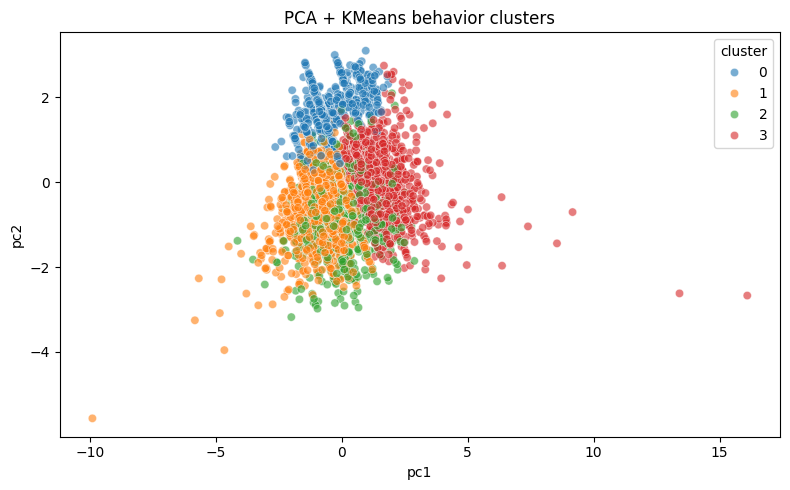

Explained variance ratio: [0.23061215 0.17490639]


,aggression_score,strength_mean,preflop_equity,table_position,starting_stack,win_streak,loss_streak
cluster,,,,,,,
0,0.690617,0.504043,0.338852,1.000000,492.379952,0.306504,0.414416
1,0.267579,0.498505,0.251071,0.123793,603.346255,0.139726,1.573960
2,0.970893,0.502335,0.775523,0.143853,639.672811,0.524603,1.058824
3,1.761816,0.501718,0.289211,0.146209,660.470998,1.964470,0.069549


In [9]:
cluster_cols = [c for c in [
    "aggression_score", "strength_mean", "preflop_equity", "table_position",
    "starting_stack", "win_streak", "loss_streak"
] if c in clean_df.columns]

cluster_view = clean_df[cluster_cols].copy().apply(pd.to_numeric, errors="coerce").fillna(0.0)

if len(cluster_view) >= 50 and len(cluster_cols) >= 3:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_view)

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X_scaled)

    kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=20)
    clusters = kmeans.fit_predict(X_scaled)

    pca_df = pd.DataFrame({"pc1": X_pca[:, 0], "pc2": X_pca[:, 1], "cluster": clusters})

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=pca_df.sample(min(len(pca_df), 5000), random_state=RANDOM_SEED), x="pc1", y="pc2", hue="cluster", alpha=0.6, palette="tab10")
    plt.title("PCA + KMeans behavior clusters")
    plt.tight_layout()
    plt.show()

    print("Explained variance ratio:", pca.explained_variance_ratio_)
    cluster_profile = pd.concat([cluster_view, pd.Series(clusters, name="cluster")], axis=1).groupby("cluster").mean(numeric_only=True)
    display(cluster_profile)
else:
    print("Not enough data/columns for PCA + clustering block.")

### Interpretation (dimensionality reduction)

**Explained variance ratio** per principal component tells you how much of the total variance the first PCs capture (if PC1+PC2 are low, the 2D plot is only a weak summary). 

The PCA projection gives an interpretable low-dimensional view of player behavior, while clustering groups similar strategy profiles. These profiles can support future personalization (for example, opponent-specific bluff calibration).

## 5d) Action recommendation (fold / call / raise):

### Decision we are modeling
At player decision points, the engine exposes **three legal buckets**: **fold**, **call** (includes **check** when not facing a bet), and **raise** (bet or raise-to). 

### What “effective” should mean here (not the same as maximum EV)
- **Actionable:** outputs must be exactly **fold**, **call**, or **raise** with a **0–100 confidence** that reflects *how strongly* the model prefers its top class.
- **Non-leaky:** training labels must not use information the player does not know at decision time (e.g. future board cards or opponents’ hole cards). 

### Features that matter (and why)
| Feature family | Rationale |
|----------------|-----------|
| **Equity / win proxy** | Primary driver of whether folding is tolerable vs continuing. |
| **Price vs stack** (`call/stack`, `pot/stack`) | Pot odds and stack pressure; central to fold vs call. |
| **Facing bet** | Switches the semantics of “call” (pay vs check). |
| **Raise sizing bounds** (`min_raise`, `max_raise`) | Captures whether aggression is even *meaningfully* available. |
| **Street one-hot** | Same absolute bet means different things preflop vs river. |
| **Villains still in** | Multway dilutes equity; models that ignore it mis-rank folds. |
| **Hero money already in** | Sunk cost bias is real for humans; the model should see **committed chips** as context (not as a reason to *call* by itself — that is learned from labels). |
| **Opponent bluff proxies** | Only **visible** estimates; may nudge call frequency on scary boards. |


The live **`action_advisor.py`** uses the same **16-dimensional** feature construction, then applies the following:

- **Fold sanity:** e.g. **preflop garbage** (defined ranks / weak pairs) **always fold** when `call_amount > 0`
- **Postflop:** **straight or better** (`hand_strength` tier **≥ 5**) with **win proxy ≥ ~0.44** 


In [10]:
from pathlib import Path
import runpy

_root = Path.cwd()
if (_root / "notebooks").is_dir():
    script = _root / "notebooks" / "_train_action_advisor_export.py"
elif (_root.parent / "notebooks").is_dir():
    script = _root.parent / "notebooks" / "_train_action_advisor_export.py"
else:
    script = Path("..") / "notebooks" / "_train_action_advisor_export.py"

if script.resolve().exists():
    runpy.run_path(str(script.resolve()), run_name="__main__")
else:
    print("Skip: could not find", script)


oracle label fold: 0.143
oracle label call: 0.575
oracle label raise: 0.282
Wrote C:\Users\garrido-lestachebeli\CLASSES\Sophmore\semester 2\DataScience\FinalProject\gambling\poker_page\action_model.json (train acc on synthetic oracle ~0.780)
  recall fold: 0.970
  recall call: 0.739
  recall raise: 0.766


SystemExit: 0

C:\Users\garrido-lestachebeli\AppData\Roaming\Python\Python314\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# 1000-hand simulation

We want to test if our predictors will make a profit over 1000 hands played

- **Hero** only acts according to `action_advisor.predict_decision_advisor` (fold / call / raise).
- **Raises:** when the advisor says **raise**, the simulation picks a **raise-to** total `min(min_raise + extra, max_raise)` where `extra` is **5** on the hero’s first raise of the hand, **10** on the second, **20** on the third, etc.
- Bots use the same `poker_core.run_one_bot_turn` stack as the live app.

In [11]:
import sys
from pathlib import Path

# Allow running from repo root OR notebooks/ by resolving poker_page/ dynamically.
_cwd = Path.cwd().resolve()
_candidates = (_cwd / "poker_page", _cwd.parent / "poker_page")
for _pp in _candidates:
    if _pp.is_dir():
        _pp_s = str(_pp)
        if _pp_s not in sys.path:
            sys.path.insert(0, _pp_s)
        break

import poker_core  # noqa: E402
from game_state import GameState  # noqa: E402

N_HANDS = 10000
MAX_STEPS_PER_HAND = 8000


def choose_raise_to_amount(gs, view: dict, hero_raise_index: int) -> int | None:
    """Return legal raise-to total, or None if no raise is legal."""
    state = gs.poker_state
    if state is None:
        return None
    min_r = int(view["min_raise"])
    max_r = int(view["max_raise"])
    extra = 5 * (2**hero_raise_index)
    want = min(max_r, max(min_r, min_r + extra))
    for cand in (want, max_r, min_r):
        if state.can_complete_bet_or_raise_to(int(cand)):
            return int(cand)
    return None


def play_one_hand(gs: GameState) -> dict:
    """Play until terminal; return row dict of outcomes."""
    hero = int(gs.hero)
    start_stack = int((gs.master_bankrolls or [0])[hero])
    hero_raise_idx = 0
    steps = 0
    folds = 0
    calls = 0
    raises = 0
    err_raise_fallback = 0

    while steps < MAX_STEPS_PER_HAND:
        steps += 1
        poker_core.run_dealer(gs)
        ps = gs.poker_state
        if ps is None or not bool(getattr(ps, "status", True)):
            poker_core.capture_terminal_if_needed(gs)
            break
        ti = poker_core.live_turn_seat(gs)
        if ti is None:
            poker_core.capture_terminal_if_needed(gs)
            break
        if ti == hero:
            view = poker_core.build_view(gs)
            rec = (view.get("action_advisor_action") or "call").lower()
            if rec == "fold":
                poker_core.apply_hero_action(gs, {"type": "fold"})
                folds += 1
            elif rec == "call":
                poker_core.apply_hero_action(gs, {"type": "call"})
                calls += 1
            elif rec == "raise":
                amt = choose_raise_to_amount(gs, view, hero_raise_idx)
                if amt is not None:
                    poker_core.apply_hero_action(gs, {"type": "raise", "amount": amt})
                    if gs.action_error:
                        gs.action_error = ""
                        poker_core.apply_hero_action(gs, {"type": "call"})
                        err_raise_fallback += 1
                    else:
                        raises += 1
                        hero_raise_idx += 1
                else:
                    poker_core.apply_hero_action(gs, {"type": "call"})
                    err_raise_fallback += 1
            else:
                poker_core.apply_hero_action(gs, {"type": "call"})
                calls += 1
            poker_core.run_dealer(gs)
        else:
            poker_core.run_one_bot_turn(gs)

    end_stack = int((gs.master_bankrolls or [0])[hero])
    pay = poker_core.build_view(gs).get("payoffs") or []
    hero_pay = int(pay[hero]) if hero < len(pay) else 0
    return {
        "hand_steps": steps,
        "hero_start_stack": start_stack,
        "hero_end_stack": end_stack,
        "hero_net_chips": end_stack - start_stack,
        "hero_payoff_last_view": hero_pay,
        "hero_folds": folds,
        "hero_calls": calls,
        "hero_raises": raises,
        "illegal_raise_fallbacks": err_raise_fallback,
    }


gs = GameState()
gs.hero = 0
poker_core.ensure_initialized(gs)

rows: list[dict] = []
for h in range(N_HANDS):
    if h > 0:
        poker_core.new_hand(gs, advance_button=True)
    rows.append(play_one_hand(gs))

df = pd.DataFrame(rows)
print(df.describe().T)
print("\nCumulative hero net chips:", int(df["hero_net_chips"].sum()))
print("Mean net per hand:", float(df["hero_net_chips"].mean()))
print(
    "Advisor mix (approx):",
    {
        "folds": int(df["hero_folds"].sum()),
        "calls": int(df["hero_calls"].sum()),
        "raises": int(df["hero_raises"].sum()),
        "raise→call_fallbacks": int(df["illegal_raise_fallbacks"].sum()),
    },
)
df.head(10)

                           count        mean           std      min     25%      50%      75%      max
hand_steps               10000.0     24.0004      5.306450      6.0    21.0     24.0     27.0     50.0
hero_start_stack         10000.0  28719.5757  23456.492747      1.0  9955.0  26833.0  43246.5  92237.0
hero_end_stack           10000.0  28726.4530  23458.747425      0.0  9956.5  26835.5  43248.0  92237.0
hero_net_chips           10000.0      6.8773    638.975109 -13120.0    -6.0     -2.0      0.0  39177.0
hero_payoff_last_view    10000.0      6.8773    638.975109 -13120.0    -6.0     -2.0      0.0  39177.0
hero_folds               10000.0      0.5653      0.495742      0.0     0.0      1.0      1.0      1.0
hero_calls               10000.0      2.6473      2.431562      0.0     0.0      2.0      5.0     11.0
hero_raises              10000.0      0.2544      0.758774      0.0     0.0      0.0      0.0     10.0
illegal_raise_fallbacks  10000.0      0.0000      0.000000      0.0     0

,hand_steps,hero_start_stack,hero_end_stack,hero_net_chips,hero_payoff_last_view,hero_folds,hero_calls,hero_raises,illegal_raise_fallbacks
0,14,200,115,-85,-85,0,0,4,0
1,25,115,110,-5,-5,1,3,0,0
2,22,110,110,0,0,1,0,0,0
3,28,110,110,0,0,1,0,0,0
4,22,110,118,8,8,0,4,0,0
5,22,118,116,-2,-2,1,2,0,0
6,21,116,107,-9,-9,1,2,1,0
7,20,107,96,-11,-11,1,3,1,0
8,31,96,96,0,0,1,0,0,0
9,30,96,92,-4,-4,1,3,0,0


## 6) Data Modeling and Prediction

### What we are doing
Train and evaluate two classification models:
1. Stage-based win chance (`won_flag`)
2. Visible-feature bluff probability (`is_bluffing`)

### Important methodology choice
We split by `hand_id` using `GroupShuffleSplit` to reduce leakage between train and test.

### Modeling stack (what you are training)

- **Stage win models:** For each stage we expand every CSV row into one training row with target `won_flag`. We fit a **RandomForestClassifier**, then wrap it in **CalibratedClassifierCV** so probabilities are closer to frequencies on held-out *groups*. Metrics (accuracy, ROC AUC, Brier, macro F1) are printed per stage; the helper also plots a calibration curve and prints `classification_report` + confusion matrix for interpretability.
- **Visible bluff model:** `build_visible_bluff_frame` deliberately avoids starting cards.
- **Regression:** A separate **LinearRegression** + bootstrap on `net_result` as a sanity check.


2. **Visible-bluff model (following cell):** Same style metrics plus a **confusion matrix** where **bluff = 1** is often tiny. **High accuracy + low bluff recall** usually means “almost always predict non-bluff,” not that bluffs were found.

3. **Regression add-on (later):** **R²**, **MSE**, fitted coefficients, and **bootstrap** intervals — a **linear** explanation of `net_result`. Low R² does not invalidate the random forests above; it only says chip swings are noisy vs a linear feature set.


--- Calibration plot (read with the diagonal) ---
Each point = one bin of predicted P(positive). **x** = mean predicted probability in that bin; **y** = actual fraction of positives among rows in that bin.
The gray dashed line is **perfect calibration** (predicted frequency matches empirical frequency). Points **below** the line ⇒ model is **over-confident** (predicts high positives more often than reality); **above** the line ⇒ **under-confident**.
Isotonic calibration in `CalibratedClassifierCV` tries to bend the forest scores toward this diagonal on training folds.



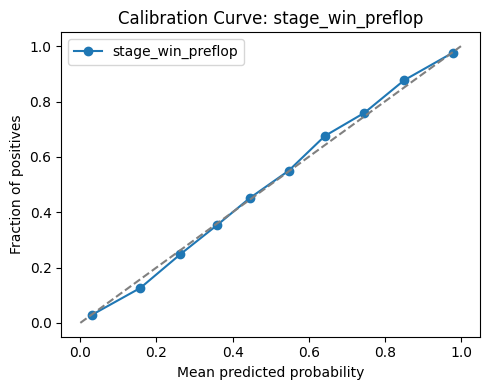


stage_win_preflop classification report:

              precision    recall  f1-score   support

           0       0.66      0.88      0.76     12135
           1       0.67      0.34      0.45      8377

    accuracy                           0.66     20512
   macro avg       0.66      0.61      0.60     20512
weighted avg       0.66      0.66      0.63     20512

Confusion matrix:
[[10726  1409]
 [ 5544  2833]]

--- Calibration plot (read with the diagonal) ---
Each point = one bin of predicted P(positive). **x** = mean predicted probability in that bin; **y** = actual fraction of positives among rows in that bin.
The gray dashed line is **perfect calibration** (predicted frequency matches empirical frequency). Points **below** the line ⇒ model is **over-confident** (predicts high positives more often than reality); **above** the line ⇒ **under-confident**.
Isotonic calibration in `CalibratedClassifierCV` tries to bend the forest scores toward this diagonal on training folds.



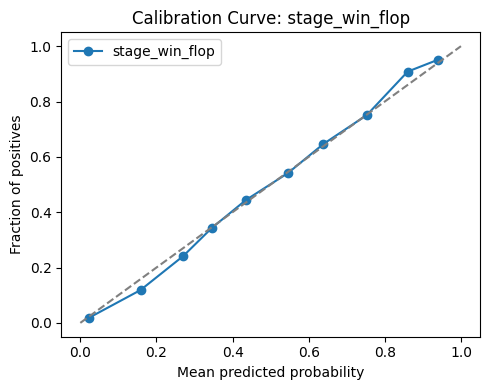


stage_win_flop classification report:

              precision    recall  f1-score   support

           0       0.67      0.86      0.75     12135
           1       0.65      0.38      0.48      8377

    accuracy                           0.66     20512
   macro avg       0.66      0.62      0.62     20512
weighted avg       0.66      0.66      0.64     20512

Confusion matrix:
[[10383  1752]
 [ 5157  3220]]

--- Calibration plot (read with the diagonal) ---
Each point = one bin of predicted P(positive). **x** = mean predicted probability in that bin; **y** = actual fraction of positives among rows in that bin.
The gray dashed line is **perfect calibration** (predicted frequency matches empirical frequency). Points **below** the line ⇒ model is **over-confident** (predicts high positives more often than reality); **above** the line ⇒ **under-confident**.
Isotonic calibration in `CalibratedClassifierCV` tries to bend the forest scores toward this diagonal on training folds.



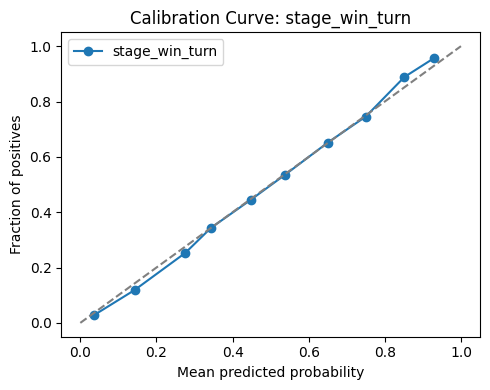


stage_win_turn classification report:

              precision    recall  f1-score   support

           0       0.67      0.86      0.76     12135
           1       0.66      0.39      0.49      8377

    accuracy                           0.67     20512
   macro avg       0.67      0.63      0.62     20512
weighted avg       0.67      0.67      0.65     20512

Confusion matrix:
[[10461  1674]
 [ 5095  3282]]

--- Calibration plot (read with the diagonal) ---
Each point = one bin of predicted P(positive). **x** = mean predicted probability in that bin; **y** = actual fraction of positives among rows in that bin.
The gray dashed line is **perfect calibration** (predicted frequency matches empirical frequency). Points **below** the line ⇒ model is **over-confident** (predicts high positives more often than reality); **above** the line ⇒ **under-confident**.
Isotonic calibration in `CalibratedClassifierCV` tries to bend the forest scores toward this diagonal on training folds.



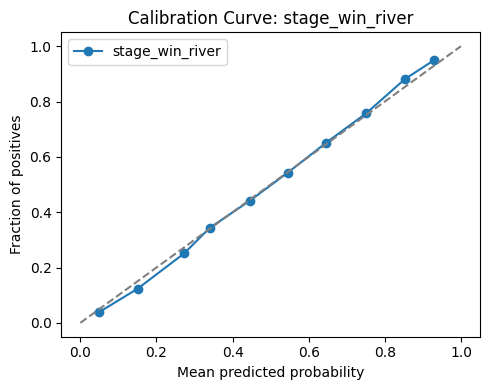


stage_win_river classification report:

              precision    recall  f1-score   support

           0       0.68      0.88      0.77     12135
           1       0.69      0.39      0.50      8377

    accuracy                           0.68     20512
   macro avg       0.69      0.64      0.63     20512
weighted avg       0.68      0.68      0.66     20512

Confusion matrix:
[[10690  1445]
 [ 5085  3292]]


,model,rows,accuracy,auc,brier,f1
3,stage_win_river,102615,0.681650,0.722439,0.201452,0.502059
2,stage_win_turn,102615,0.669998,0.707351,0.205943,0.492312
1,stage_win_flop,102615,0.663173,0.695452,0.209417,0.482433
0,stage_win_preflop,102615,0.661028,0.692261,0.211782,0.449005



Top features for preflop


,feature,importance
10,spr,0.364318
7,preflop_strength,0.141442
8,hero_stack_bb,0.119514
9,effective_stack_bb,0.118359
1,hole_rank_low,0.079250
0,hole_rank_high,0.058486
4,rank_gap,0.047815
2,is_pair,0.027727



Top features for flop


,feature,importance
10,spr,0.400531
8,hero_stack_bb,0.107998
9,effective_stack_bb,0.107379
0,hand_strength,0.087968
18,shared_strength_gap,0.071801
6,board_high_rank,0.064278
19,board_shared_strength_risk,0.044005
1,pair_count,0.041458



Top features for turn


,feature,importance
10,spr,0.373689
0,hand_strength,0.096072
8,hero_stack_bb,0.094488
9,effective_stack_bb,0.093574
18,shared_strength_gap,0.087889
19,board_shared_strength_risk,0.066844
6,board_high_rank,0.064081
1,pair_count,0.040432



Top features for river


,feature,importance
7,spr,0.351687
0,hand_strength,0.115459
15,shared_strength_gap,0.110282
6,effective_stack_bb,0.088474
5,hero_stack_bb,0.087116
16,board_shared_strength_risk,0.079961
3,board_high_rank,0.058863
1,pair_count,0.038594


In [12]:
# Train stage win models (preflop/flop/turn/river)
stage_models = {}
stage_metrics = []
stage_importances = {}

for stage in ["preflop", "flop", "turn", "river"]:
    stage_frame = build_stage_training_frame(clean_df, stage)
    needed = [c for c in STAGE_FEATURES[stage] if c in stage_frame.columns]
    if len(stage_frame) < 100 or len(needed) < 5:
        print(f"Skipping {stage}: insufficient rows or features.")
        continue
    model, m, imp = evaluate_classifier_with_group_split(
        stage_frame,
        features=needed,
        target="won_flag",
        group_col="hand_id",
        label=f"stage_win_{stage}",
    )
    stage_models[stage] = model
    stage_metrics.append(m)
    stage_importances[stage] = imp

stage_metrics_df = pd.DataFrame(stage_metrics).sort_values("auc", ascending=False)
display(stage_metrics_df if not stage_metrics_df.empty else pd.DataFrame({"info": ["No stage models trained"]}))

for stage, imp in stage_importances.items():
    print(f"\nTop features for {stage}")
    display(imp.head(8))


--- Calibration plot (read with the diagonal) ---
Each point = one bin of predicted P(positive). **x** = mean predicted probability in that bin; **y** = actual fraction of positives among rows in that bin.
The gray dashed line is **perfect calibration** (predicted frequency matches empirical frequency). Points **below** the line ⇒ model is **over-confident** (predicts high positives more often than reality); **above** the line ⇒ **under-confident**.
Isotonic calibration in `CalibratedClassifierCV` tries to bend the forest scores toward this diagonal on training folds.



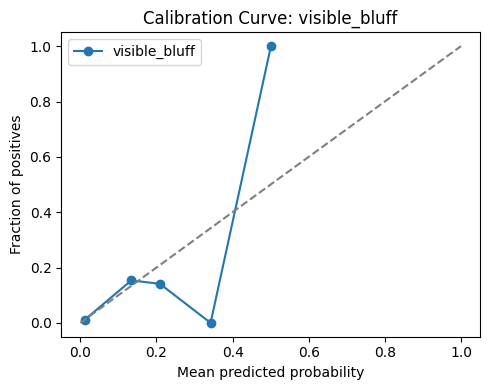


visible_bluff classification report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     20003
           1       1.00      0.00      0.00       509

    accuracy                           0.98     20512
   macro avg       0.99      0.50      0.50     20512
weighted avg       0.98      0.98      0.96     20512

Confusion matrix:
[[20003     0]
 [  508     1]]


,model,rows,accuracy,auc,brier,f1
0,visible_bluff,102615,0.975234,0.915978,0.0219,0.003922


,feature,importance
20,seat_bet_to_pot,0.215662
19,spr,0.184319
21,seat_raise_count,0.129060
18,effective_stack_bb,0.093728
17,hero_stack_bb,0.090970
7,board_high_rank,0.076959
22,street_phase,0.067524
16,board_only_strength,0.037850
1,hand_strength,0.035821
0,position_value,0.023055


In [13]:
# Train visible bluff model
bluff_frame = build_visible_bluff_frame(clean_df)
bluff_features = [c for c in VISIBLE_BLUFF_FEATURES if c in bluff_frame.columns]

bluff_model = None
bluff_metrics_df = pd.DataFrame()
bluff_importance = pd.DataFrame()

if len(bluff_frame) >= 100 and len(bluff_features) >= 5:
    bluff_model, bluff_metrics, bluff_importance = evaluate_classifier_with_group_split(
        bluff_frame,
        features=bluff_features,
        target="is_bluffing",
        group_col="hand_id",
        label="visible_bluff",
    )
    bluff_metrics_df = pd.DataFrame([bluff_metrics])
    display(bluff_metrics_df)
    display(bluff_importance.head(12))
else:
    print("Skipping visible bluff model: insufficient rows/features")

### Regression add-on

We include a compact regression analysis to model `net_result` from selected numeric features, then bootstrap coefficient stability.

**Code below** Prints **train/test R² and MSE**, **OLS coefficients**, and **bootstrap percentile intervals** for each coefficient. **Positive coef** = higher feature values associate with higher `net_result` *holding others linearly fixed* in this simple model — not causal. Wide bootstrap bands mean the sign is unstable across resamples.

Linear regression RMSE: 137.0572


,feature,coef
5,win_streak,54.838372
4,starting_stack,-8.758576
3,table_position,8.644057
0,aggression_score,2.765129
1,preflop_equity,0.454188
2,strength_mean,0.364141



Residual plot: x = predicted net_result on held-out rows; y = actual - predicted. Ideal linear+Gaussian errors ≈ symmetric cloud around 0; funnels/curves mean OLS is misspecified.



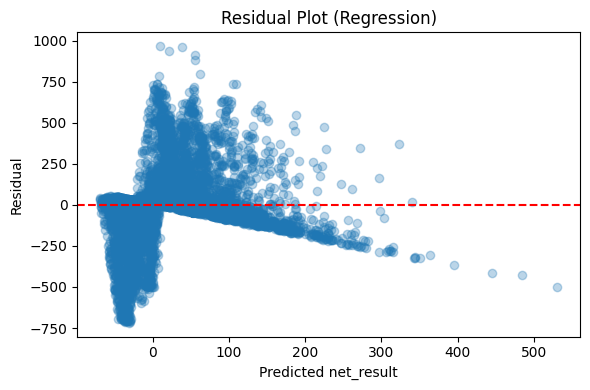

,feature,coef_mean,coef_std,pct_positive
5,win_streak,58.460743,1.457028,100.0
0,aggression_score,1.472728,0.880677,94.5
1,preflop_equity,0.469651,0.520473,82.5
3,table_position,8.819517,0.464553,100.0
2,strength_mean,0.417250,0.427864,85.5
4,starting_stack,-9.575085,0.376866,0.0


In [14]:
# Linear regression + bootstrap coefficient stability
reg_features = [c for c in [
    "aggression_score", "preflop_equity", "strength_mean", "table_position", "starting_stack", "win_streak"
] if c in clean_df.columns]

if reg_features and "net_result" in clean_df.columns:
    reg_df = clean_df[reg_features + ["net_result"]].copy()
    reg_df = reg_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    X = reg_df[reg_features]
    y = reg_df["net_result"]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=reg_features)

    split = int(0.8 * len(X_scaled))
    X_train, X_test = X_scaled.iloc[:split], X_scaled.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    print("Linear regression RMSE:", round(float(rmse), 4))

    coef_df = pd.DataFrame({"feature": reg_features, "coef": lr.coef_}).sort_values("coef", key=np.abs, ascending=False)
    display(coef_df)

    # Residual view (actual - predicted vs predicted)
    print(
        "\nResidual plot: x = predicted net_result on held-out rows; y = actual - predicted. "
        "Ideal linear+Gaussian errors ≈ symmetric cloud around 0; funnels/curves mean OLS is misspecified.\n"
    )
    residuals = y_test - y_pred
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title("Residual Plot (Regression)")
    plt.xlabel("Predicted net_result")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # Bootstrap coefficient signs
    B = 200
    coef_rows = []
    n = len(X_scaled)
    for _ in range(B):
        idx = np.random.choice(n, size=n, replace=True)
        xb = X_scaled.iloc[idx]
        yb = y.iloc[idx]
        m = LinearRegression().fit(xb, yb)
        coef_rows.append(m.coef_)
    boot = pd.DataFrame(coef_rows, columns=reg_features)
    boot_summary = pd.DataFrame({
        "feature": reg_features,
        "coef_mean": boot.mean().values,
        "coef_std": boot.std().values,
        "pct_positive": (boot > 0).mean().values * 100,
    }).sort_values("coef_std", ascending=False)
    display(boot_summary)
else:
    print("Skipping regression block: required columns not available.")

### Interpretation (modeling)

**How this ties to the cells above:** The **grouped metrics table** (one row per street) is evaluated on held-out **hands**; the **`classification_report`** blocks use a readable subset of test rows. **Feature importances** are *within-model* rankings (tree splits), not causal effects. The **bluff** matrix is the critical view for H2 — **accuracy is not enough**.

Holdout metrics from this notebook’s last run (see cells above):

**Stage win models (grouped eval, ~102k rows per stage):** ROC AUC rises from **preflop ~0.69** to **river ~0.72**; accuracy from **~0.66** to **~0.68**; Brier improves slightly (**~0.21 → ~0.20**); macro F1 **~0.45 → ~0.50**. Classification reports on the ~20k-row fold show **win-class recall ~0.35–0.39** and **loss-class recall ~0.86–0.88**—the model is conservative about predicting wins, which matches the class imbalance.

**Visible-bluff model:** accuracy is very high (**~0.98**) because bluffs are rare (~0.3% positives); AUC **~0.92** but **F1 near zero**—the confusion matrix shows almost no true bluffs predicted. Treat bluff scores as exploratory unless rebalancing or threshold tuning is applied.

**Regression Model:** the data (and the way poker money is won/lost) is structured in a way a linear regression is not built to respect without a different target definition, transforms, or a different model family.

## 7) Results Analysis

### Bias and limitations
- Hand-history populations may not represent all player pools/stakes.
- Temporal and opponent adaptation effects are only partially captured.

### Potential negative implications
- Over-reliance on model output can reduce human strategic flexibility.
- Models may amplify historical biases from specific pools/opponents.
- Misuse in competitive settings may not be allowed.

### Improvements
- Add richer externally validated labels and stronger hand-evaluation ground truth.
- Perform opponent-segment calibration and temporal drift checks.
- Add uncertainty intervals directly on live predictions.
- Run repeated grouped CV and threshold optimization for deployment.

## Conclusion

### What this project actually did

We took messy **real poker hand histories**, treated them like a normal data-science pipeline, and walked them all the way through: **describe the table → clean and coerce → stare at missingness and quality → EDA and correlations → a few hypothesis tests → PCA and k-means as a “what kinds of patterns show up?” side trip → supervised models** 

### What we learned from the numbers

The **win** models are in a believable range for this setup, an **AUC in the high 0.6s to low 0.7s**. The **bluff** model's labels are **wildly imbalanced**, so you can get a flashy accuracy number while the model barely catches true bluffs; trust the **confusion matrix and F1**.

We showed you can **turn table behavior into numbers and test them honestly** — the model's dont capture enough information about the game to make reliable betting advice. That being said, there is a lot to take away from this project about how to process real data, and extract meaningful information from it.